# A.9 找到一條資訊，就代表讀懂長文嗎？


沿用上一節的八筆紀錄，固定它們的排列，不再移動線索。問「攝影社的活動室代碼」只要答 `M17`；若改問三個社團的代碼，答案就要有三筆；若問攝影社的活動室在幾樓，還得把社團與樓層接起來。材料相同，三種問題需要用到資訊的方式卻不同。

下表再列出這次會用到的四筆，其餘四筆仍保留原樣。

| 紀錄標籤 | 原文 |
| --- | --- |
| T | 攝影社的活動室代碼是 M17。 |
| U1 | 棋藝社的活動室代碼是 B04。 |
| U2 | 合唱社的活動室代碼是 C26。 |
| U3 | M17 在二樓。 |

先只查一筆：「攝影社的活動室代碼是什麼？」T 已直接給出 `M17`，不需要讀 U3 才能回答。常見的「在長材料中找一根針」測試，就是把這種短線索放進許多其他文字，檢查能否取回指定資訊。答對說明這次找到了所問的代碼，還沒有檢查是否能列全多筆資料，或連接分散的關係。

接著只增加要取回的筆數：「按攝影社、棋藝社、合唱社的順序，列出各自的活動室代碼。」紙上答案是 `M17、B04、C26`，分別來自 T、U1、U2。三筆之間不用推導，只要每筆取對並照要求列全。若回答 `M17、B04`，已找對兩筆，仍漏了合唱社；若多加 `E31`，則帶入題目沒有要求的美術社。完整取回要同時檢查漏項、錯配與多項，不能只看答案裡是否出現 `M17`。

第三次仍用同一份紀錄，改問：「攝影社的活動室在幾樓？」這回不能直接抄 T，也不能看見某筆寫「一樓」就選它。先依 T 得到房間 `M17`，再用這個代碼對上 U3，才得到「二樓」。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

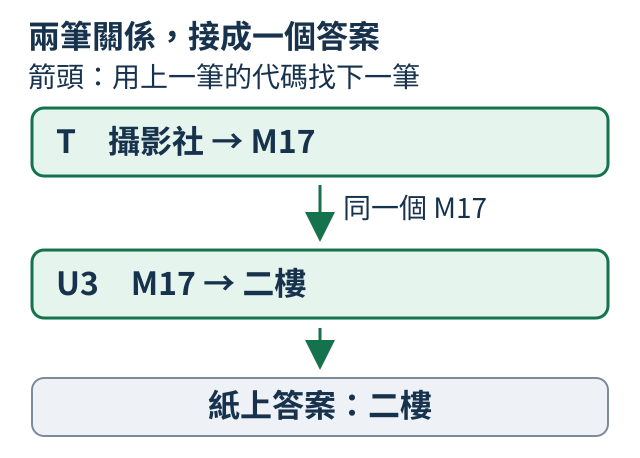

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-A-linked-records.svg")))

圖中的箭頭表示「把第一筆得到的代碼，用來找第二筆」，不是說模型一定照這兩步運算。我們能直接核對的是答案是否與兩筆紀錄一致。若答「一樓」，可能把 U1 的棋藝社→B04，接上 U4「B04 在一樓」的路徑，錯套到攝影社；若只答 `M17`，則停在房間代碼，還沒有回答樓層。這些錯例的用途，是指出回答缺了哪個關係，不是替模型的內部過程下定論。

三種題目的期待答案可以放在一起看：

| 需要完成的工作 | 紙上答案 | 核對的重點 |
| --- | --- | --- |
| 取回一筆 | M17 | 社團與代碼是否對應 |
| 取回指定三筆 | M17、B04、C26 | 是否列全、無多項且順序正確 |
| 組合兩筆關係 | 二樓 | 樓層是否符合 T、U3 的共同對應 |

真正評測時，這三類應分開記錄，再各自增加長度或移動必要線索。組合題要保留兩筆相關紀錄，不能刪掉 U3 後還期待模型答出樓層。也先用只有必要紀錄的短版檢查同題能否完成；若短版已接錯關係，就不能把長版失敗全歸因於資料太遠。比較位置時仍按上一節固定總長度與生成設定。

單筆取回、多筆取回與組合線索，都只是長文能力的一部分。整理活動手冊的摘要還要判斷哪些內容重要，核對多份公告可能還要處理版本衝突，這些工作沒有被上述代碼題涵蓋。教材因此按「答案需要哪些資訊」安排驗收，而不把某次找到一個代碼當成整份長文都讀懂的證據。

<details>
<summary>補充：來源與例子的界線</summary>

Hsieh et al., [*RULER: What's the Real Context Size of Your Long-Context Language Models?*，arXiv:2404.06654v3](https://arxiv.org/pdf/2404.06654v3)，§3.1–3.4、Table 2，區分單筆取回、多筆取回與多步追蹤等任務；本節借用這個區分，沒有重現完整 benchmark。

[*Lost in the Middle*](https://arxiv.org/pdf/2307.03172v3) 的多文件問答在 §2 使用多份文件，但恰好只有一份含答案，不能僅從「多文件」名稱推論它驗收了跨文件組合。Bai et al., [*LongBench*，arXiv:2308.14508v2](https://arxiv.org/pdf/2308.14508v2)，§3.2.1，則涵蓋摘要及包含多跳資料集的多文件問答，說明長文任務還有其他要求。本節展示的都是人工可核對的材料與答案，沒有訓練或模型成績。

</details>
